# Training a Machine Learning Model for Data Quality Detection and Curation of MNIST dataset

Install required packages

In [20]:
%%capture
!uv pip install fiftyone==1.7.0 torch==2.6.0 torchvision==0.21 numpy==2.0.2 open-clip-torch==3.2.0

In [21]:
# Plug-in to evaluate the performance of our classification models
!fiftyone plugins download \
    https://github.com/voxel51/fiftyone-plugins \
    --plugin-names @voxel51/evaluation


Skipping existing plugin '@voxel51/evaluation'


In [22]:
# Plug-in for image augmentations
!fiftyone plugins download https://github.com/jacobmarks/fiftyone-albumentations-plugin


Skipping existing plugin '@jacobmarks/albumentations_augmentation'


Import packages

In [23]:
import os

# Set environment variables for reproducibility BEFORE importing torch
os.environ['PYTHONHASHSEED'] = '51'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fun
import torchvision
import torchvision.transforms.v2 as transforms
import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from torch.utils.data import Dataset, ConcatDataset
from fiftyone import ViewField as F
import fiftyone.utils.random as four
from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
import matplotlib.pyplot as plt
import gc
import albumentations as A
import cv2
import random
from typing import Optional, Dict, Tuple, Any
import open_clip

# Check installed versions
(fo.__version__, torch.__version__,
 torchvision.__version__, np.__version__,
 open_clip.__version__)

('1.7.0', '2.6.0+cu124', '0.21.0+cu124', '2.0.2', '3.2.0')

Set seeds for reproducibility

In [24]:
def set_seeds(seed=51):
    """
    Set seeds for complete reproducibility across all libraries and operations.

    Args:
        seed (int): Random seed value
    """
    # Set environment variables before other imports
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

    # Python random module
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch GPU (all devices)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

        # CUDA deterministic operations
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # OpenCV
    cv2.setRNGSeed(seed)

    # Albumentations (for data augmentation)
    try:
        A.seed_everything(seed)
    except AttributeError:
        # Older versions of albumentations
        pass

    # PyTorch deterministic algorithms (may impact performance)
    try:
        torch.use_deterministic_algorithms(True)
    except RuntimeError:
        # Some operations don't have deterministic implementations
        print("Warning: Some operations may not be deterministic")

    print(f"All random seeds set to {seed} for reproducibility")



# Usage: Call this function at the beginning and before each training phase
set_seeds(51)

# Additional reproducibility considerations:

def create_deterministic_training_dataloader(dataset, batch_size, shuffle=True, **kwargs):
    """
    Create a DataLoader with deterministic behavior.

    Args:
        dataset: PyTorch Dataset instance
        batch_size: Batch size
        shuffle: Whether to shuffle data
        **kwargs: Additional DataLoader arguments

    Returns:
        Training DataLoader with reproducible behavior
    """
    # Use a generator with fixed seed for reproducible shuffling
    generator = torch.Generator()
    generator.manual_seed(51)

    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        **kwargs
    )

# Example usage:
# train_loader = create_deterministic_dataloader(
#     torch_train_set,
#     batch_size=64,
#     shuffle=True,
#     num_workers=4,
#     pin_memory=True
# )



All random seeds set to 51 for reproducibility


Create the modern vesion of LeNet-5

In [25]:
class ModernLeNet5(nn.Module):
    """
    Modernized version of LeNet-5 with ReLU activations and max pooling.
    Often performs better on MNIST than the original version.
    """

    def __init__(self, num_classes=10):
        super(ModernLeNet5, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=4)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, num_classes)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(Fun.relu(self.conv1(x)))
        x = self.pool(Fun.relu(self.conv2(x)))
        x = Fun.relu(self.conv3(x))

        x = x.view(x.size(0), -1)
        x = Fun.relu(self.fc1(x))
        x = self.dropout(x)  # Add dropout for regularization
        x = self.fc2(x)

        return x


Download MNIST training dataset from FiftyOne's Zoo

In [26]:
# We use the training split to train our LeNet model
# We make this dataset persistent as we want to save our changes for multiple sessions
train_val_dataset = foz.load_zoo_dataset("mnist",
                                         split='train',
                                         dataset_name="mnist-train-val",
                                         persistent=True)

train_val_dataset.compute_metadata()

Split 'train' already downloaded


INFO:fiftyone.zoo.datasets:Split 'train' already downloaded


Loading existing dataset 'mnist-train-val'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


INFO:fiftyone.zoo.datasets:Loading existing dataset 'mnist-train-val'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


Split training dataset into training and validation datasets at 80:20 ratio

In [27]:
train_val_dataset.untag_samples(["train", "validation"])

In [35]:
import fiftyone as fo

# List all existing datasets
existing_datasets = fo.list_datasets()

# Check and delete 'mnist-training-set' if it exists
if "mnist-training-set" in existing_datasets:
    print("Deleting existing dataset 'mnist-training-set'...")
    fo.delete_dataset("mnist-training-set")
    print("'mnist-training-set' deleted.")
else:
    print("'mnist-training-set' does not exist.")

# Check and delete 'mnist-validation-set' if it exists
if "mnist-validation-set" in existing_datasets:
    print("Deleting existing dataset 'mnist-validation-set'...")
    fo.delete_dataset("mnist-validation-set")
    print("'mnist-validation-set' deleted.")
else:
    print("'mnist-validation-set' does not exist.")

# Verify deletion
print("Current FiftyOne datasets:", fo.list_datasets())

Deleting existing dataset 'mnist-training-set'...
'mnist-training-set' deleted.
Deleting existing dataset 'mnist-validation-set'...
'mnist-validation-set' deleted.
Current FiftyOne datasets: ['2025.11.22.19.26.55.831905', '2025.11.22.19.26.56.484706', '2025.11.22.19.27.34.522359', '2025.11.22.19.27.35.162439', '2025.11.22.19.30.20.076120', '2025.11.22.19.30.20.723316', '2025.11.22.19.36.55.949121', '2025.11.22.19.36.56.595996', '2025.11.22.19.37.42.029734', '2025.11.22.19.37.43.644479', '2025.11.22.19.40.16.570498', '2025.11.22.19.40.17.188821', 'mnist-train-val']


In [36]:
set_seeds(51)
# Create random 80%/20% split using tags
four.random_split(train_val_dataset,
                  {"train": 0.8, "validation": 0.2},
                  # The seed makes the split reproducible
                  seed=51)

# Verify the split by counting tags
tag_counts = train_val_dataset.count_sample_tags()
print("Tag counts after split:")
print(tag_counts)

# Separate validation and train FO datasets
train_dataset = train_val_dataset.match_tags("train").clone()
val_dataset = train_val_dataset.match_tags("validation").clone()

# Set names for FO datasets using the 'name' property
train_dataset.name = "mnist-training-set"
val_dataset.name = "mnist-validation-set"

# Define persistency
train_dataset.persistent = True
val_dataset.persistent = True

# Verify no overlap between train and validation
train_ids = set(train_dataset.values("id"))
val_ids = set(val_dataset.values("id"))
overlap = train_ids.intersection(val_ids)

All random seeds set to 51 for reproducibility
Tag counts after split:
{'validation': 12000, 'train': 48000}


Convert FiftyOne dataset to Pytorch dataset

In [37]:
# Custom PyTorch Dataset class for MNIST training data
class CustomTorchImageDataset(torch.utils.data.Dataset):
    def __init__(self, fiftyone_dataset,
                 image_transforms=None,
                 label_map=None,
                 gt_field="ground_truth"):
        self.fiftyone_dataset = fiftyone_dataset
        self.image_paths = self.fiftyone_dataset.values("filepath")
        self.str_labels = self.fiftyone_dataset.values(f"{gt_field}.label")
        self.image_transforms = image_transforms

        if label_map is None:
            self.label_map = {str(i): i for i in range(10)}  # "0"->0, "1"->1, etc.
        else:
            self.label_map = label_map

        print(f"CustomTorchImageDataset initialized with {len(self.image_paths)} samples.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        try:
            image = Image.open(image_path).convert('L')
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return torch.randn(1, 28, 28), torch.tensor(-1, dtype=torch.long)

        if self.image_transforms:
            image = self.image_transforms(image)

        label_str = self.str_labels[idx]
        label_idx = self.label_map.get(label_str, -1)
        if label_idx == -1:
            print(f"Warning: Label '{label_str}' not in label_map for image {image_path}")

        return image, torch.tensor(label_idx, dtype=torch.long)

Compute mean and stadard deviation for the training dataset to improve the efficiency of training via normalization

In [38]:
def compute_stats_fiftyone(fiftyone_view):
    """
    Compute stats directly from FiftyOne using aggregations.
    Requires images to be loaded as arrays.
    """

    print("Computing image intensity statistics from FiftyOne view...")

    # Get all image filepaths
    filepaths = fiftyone_view.values("filepath")

    # Load all pixel values
    all_pixels = []

    for filepath in tqdm(filepaths):

        try:
            # Load image as grayscale array
            image = Image.open(filepath).convert('L')
            # Scale values to the range [0, 1]
            pixels = np.array(image, dtype=np.float32) / 255.0
            all_pixels.append(pixels.flatten())
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            continue

    # Concatenate all pixel values
    all_pixels = np.concatenate(all_pixels)

    # Compute statistics
    mean = np.mean(all_pixels)
    std = np.std(all_pixels)

    print(f"Computed from {len(filepaths)} images")
    print(f"Total pixels: {len(all_pixels):,}")

    return mean, std

mean_intensity, std_intensity = compute_stats_fiftyone(train_dataset)
f"Mean: {mean_intensity:.4f}, Std: {std_intensity:.4f}"

Computing image intensity statistics from FiftyOne view...


100%|██████████| 48000/48000 [00:08<00:00, 5652.54it/s]


Computed from 48000 images
Total pixels: 37,632,000


'Mean: 0.1317, Std: 0.3075'

Find the classes for labeling. A MNIST dataset should have labels from 0 to 9

In [39]:
dataset_classes = sorted(val_dataset.distinct("ground_truth.label"))
dataset_classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

Map the string labels to numerical values for the PyTorch dataset

In [40]:
label_map = {string_label: index for index, string_label in enumerate(dataset_classes)}
label_map

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

Transform the PIL images into PyTorch tensors with scaling based on stats from the training set.

In [41]:
image_transforms = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize((mean_intensity,), (std_intensity,))
])

In [42]:
torch_train_set = CustomTorchImageDataset(train_dataset,
                                          label_map=label_map,
                                          image_transforms=image_transforms)

CustomTorchImageDataset initialized with 48000 samples.


In [43]:
torch_val_set = CustomTorchImageDataset(val_dataset,
                                          label_map=label_map,
                                          image_transforms=image_transforms)

CustomTorchImageDataset initialized with 12000 samples.


Create PyTorch DataLoaders

In [44]:
# Define batch size (you can adjust this based on your GPU memory)
batch_size = 64
num_workers = os.cpu_count()  # Number of CPU cores
print(f"Number of CPU cores: {num_workers}")



Number of CPU cores: 2


In [45]:
train_loader = create_deterministic_training_dataloader(
    torch_train_set,
    batch_size=64,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

In [46]:
val_loader = torch.utils.data.DataLoader(
    torch_val_set,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data
    num_workers=num_workers,
    pin_memory=True
)

print("Train and validation DataLoaders created successfully.")
print(f"Train DataLoader has {len(train_loader)} batches.")
print(f"Validation DataLoader has {len(val_loader)} batches.")

Train and validation DataLoaders created successfully.
Train DataLoader has 750 batches.
Validation DataLoader has 188 batches.


Use Categorical Cross Entropy for multi-label classification

In [47]:
ce_loss = nn.CrossEntropyLoss()

Define two functions to handle the training and validation phases of each epoch

In [48]:
def train_epoch(model, train_loader):
  batch_losses = []
  model.train()
  for images, labels in tqdm(train_loader, desc="Training: "):
      #import pdb; pdb.set_trace()

      images = images.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(images)
      loss_value = ce_loss(logits, labels)
      # Clear gradients from previous iteration (PyTorch accumulates by default)
      optimizer.zero_grad()
      # Computes the gradients with backpropagation
      loss_value.backward()
      # Updates the weights
      optimizer.step()

      batch_losses.append(loss_value.item())

  train_loss = np.mean(batch_losses)
  return train_loss


In [49]:
def val_epoch(model, val_loader):
  batch_losses = []
  model.eval()
  with torch.inference_mode():
    for images, labels in tqdm(val_loader, desc="Validation: "):
      images = images.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(images)
      loss_value = ce_loss(logits, labels)
      batch_losses.append(loss_value.item())
  val_loss = np.mean(batch_losses)
  return val_loss

Use Adam as the optimizer

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ModernLeNet5().to(device)

# Define the optimizer (variant of stochastic gradient descent)
optimizer = Adam(model.parameters(),
                 lr=0.003, betas=(0.9, 0.999),
                 eps=1e-08, weight_decay=0)


Training can validating model. Looking for best epoch to use it for optimization.

In [51]:
# Ensure reproducibility for the training process
set_seeds(51) # You can change this number to get different results

num_epochs = 10
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model = None

# Define the path to save the model within your hard-drive
path = Path(os.getcwd()) # Feel free to change the path

model_save_path = path / 'best_lenet.pth'

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader)
    val_loss = val_epoch(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        # Save the best model
        torch.save(best_model.state_dict(), model_save_path)
        print('Found and saved better weights for the model')

All random seeds set to 51 for reproducibility


Validation: 100%|██████████| 188/188 [00:06<00:00, 28.82it/s]


Epoch 1/10 - Train Loss: 0.2278 - Val Loss: 0.0847
Found and saved better weights for the model


Validation: 100%|██████████| 188/188 [00:05<00:00, 34.78it/s]


Epoch 2/10 - Train Loss: 0.0840 - Val Loss: 0.0791
Found and saved better weights for the model


...

Epoch 8/10 - Train Loss: 0.0380 - Val Loss: 0.0754


Validation: 100%|██████████| 188/188 [00:04<00:00, 38.80it/s]


Epoch 9/10 - Train Loss: 0.0329 - Val Loss: 0.0881


Validation: 100%|██████████| 188/188 [00:04<00:00, 38.49it/s]

Epoch 10/10 - Train Loss: 0.0319 - Val Loss: 0.0803


Visualization of losses for training and validation

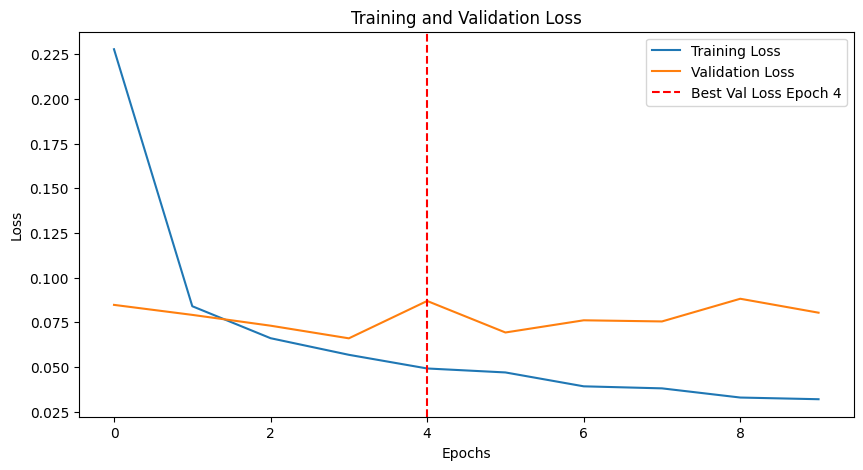

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# Find the epoch with the best validation loss
best_epoch = np.argmin(val_losses) + 1 # Add 1 because epochs are 1-indexed

# Add a vertical red line at the epoch with the best validation loss
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Val Loss Epoch {best_epoch}')
plt.legend()

plt.show()

Load the weights of the best training model into the same model architecture.

In [53]:
# Define the path where the best model was saved
path = Path(os.getcwd())
model_save_path = path / 'best_lenet.pth'

# Instantiate a new model with the same architecture
# Make sure you use the same model class that was trained
loaded_model = ModernLeNet5()

# Load the saved state dictionary into the new model instance
# Make sure the model is on the correct device (CPU or GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))

# Move the model to the device
loaded_model = loaded_model.to(device)

# Set the model to evaluation mode
loaded_model.eval()

print(f"Model loaded successfully from {model_save_path}")
print(f"Model is on device: {next(loaded_model.parameters()).device}")

Model loaded successfully from /content/best_lenet.pth
Model is on device: cuda:0


Download the test split of MNIST dataset

In [54]:
test_dataset = foz.load_zoo_dataset("mnist", split='test')

Split 'test' already downloaded


INFO:fiftyone.zoo.datasets:Split 'test' already downloaded


Loading 'mnist' split 'test'


INFO:fiftyone.zoo.datasets:Loading 'mnist' split 'test'


 100% |█████████████| 10000/10000 [6.1s elapsed, 0s remaining, 1.4K samples/s]      


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [6.1s elapsed, 0s remaining, 1.4K samples/s]      


Dataset 'mnist-test' created


INFO:fiftyone.zoo.datasets:Dataset 'mnist-test' created


Apply the best trained model to test the prediction on the test dataset

In [55]:
## Apply best_model to the test set, store logits and confidence

# Create a PyTorch Dataset for the test set
torch_test_set = CustomTorchImageDataset(test_dataset,
                                      label_map=label_map, # Use the same label map as training
                                      image_transforms=image_transforms) # Use the same transforms

# Create a PyTorch DataLoader for the test set
test_loader = torch.utils.data.DataLoader(
    torch_test_set,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle test data
    num_workers=num_workers,
    pin_memory=True
)

print("Test DataLoader created successfully.")
print(f"Test DataLoader has {len(test_loader)} batches.")

# Set the loaded model to evaluation mode
loaded_model.eval()

# Lists to store predictions and logits
predictions = []
all_logits = []

# Run inference on the test set
print("Applying best LeNet model to the test set...")
with torch.inference_mode(): # Disable gradient calculation
    for images, _ in tqdm(test_loader):
        images = images.to(device)

        # Forward pass to get logits
        logits = loaded_model(images)
        all_logits.append(logits.cpu().numpy()) # Store logits

        # Get predicted class indices
        _, predicted = torch.max(logits.data, 1)
        predictions.extend(predicted.cpu().numpy()) # Store predictions

# Concatenate logits from all batches
all_logits = np.concatenate(all_logits, axis=0)

print("Inference on test set complete.")
print(f"Shape of collected logits: {all_logits.shape}")
print(f"Number of collected predictions: {len(predictions)}")

# Store the predictions and logits back into the FiftyOne dataset as Classification objects
print("Storing predictions and logits as FiftyOne Classifications...")

for i, sample in enumerate(test_dataset):
    # Get the predicted class index and corresponding class name
    predicted_idx = predictions[i]
    predicted_label = dataset_classes[predicted_idx]

    # Get logits for this sample
    sample_logits = all_logits[i]

    # Calculate confidence scores (softmax applied to logits)
    confidences = Fun.softmax(torch.tensor(sample_logits), dim=0).numpy()
    predicted_confidence = float(confidences[predicted_idx])

    # Create FiftyOne Classification object with prediction
    classification = fo.Classification(
        label=predicted_label,
        confidence=predicted_confidence,
        logits=sample_logits.tolist()  # Store raw logits
    )

    # Store the Classification object in the sample
    sample["lenet_classification"] = classification

    sample.save()




CustomTorchImageDataset initialized with 10000 samples.
Test DataLoader created successfully.
Test DataLoader has 157 batches.
Applying best LeNet model to the test set...


100%|██████████| 157/157 [00:05<00:00, 29.20it/s]


Inference on test set complete.
Shape of collected logits: (10000, 10)
Number of collected predictions: 10000
Storing predictions and logits as FiftyOne Classifications...


Initiate FiftOne, which will be used to visualize embedding and verity the downstream analysis.

In [56]:
session = fo.launch_app(test_dataset, auto=False)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


Verify the datatype of the stored dataset to make sure it's `Classification` objects.

In [57]:
print("\n=== Verification ===")
sample = test_dataset.first()
print(f"Sample prediction type: {type(sample.lenet_classification)}")
print(f"Sample prediction: {sample.lenet_classification}")
print(f"Prediction label: {sample.lenet_classification.label}")
print(f"Prediction confidence: {sample.lenet_classification.confidence}")
print(f"Prediction logits shape: {len(sample.lenet_classification.logits)}")

session.refresh()
print(f"\nFiftyOne App URL: {session.url}")




=== Verification ===
Sample prediction type: <class 'fiftyone.core.labels.Classification'>
Sample prediction: <Classification: {
    'id': '6922132f4303ef5111129b77',
    'tags': [],
    'label': '7 - seven',
    'confidence': 1.0,
    'logits': array([-24.0100956 ,  -2.58446908,  -2.51341629,  -2.40022922,
           -14.58465385, -17.96253586, -34.65393448,  20.78087425,
           -17.05043793,  -6.89156866]),
}>
Prediction label: 7 - seven
Prediction confidence: 1.0
Prediction logits shape: 10

FiftyOne App URL: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


Check the mismatched digits.

In [58]:
# Create a view showing only LeNet's misclassifications
misclassified_view = test_dataset.match(
    F("lenet_classification.label") != F("ground_truth.label")
)
print(f"Misclassified samples: {len(misclassified_view)} samples")
print(f"Percentage of misclassified samples: {len(misclassified_view)/len(test_dataset)*100} % samples")

Misclassified samples: 120 samples
Percentage of misclassified samples: 1.2 % samples


There is 1.2% misclassified samples. To have an idea about the cause of issue, I use FiftyOne to examine those mistached images with the labels of prediction and ground truth.

In [59]:
lenet_evaluation_results = test_dataset.evaluate_classifications(
    "lenet_classification",
    gt_field="ground_truth",
    eval_key="lenet_eval")

In [60]:
session.view = misclassified_view
session.refresh()
print(session.url)

https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


Manually examiniate spotted some images are wrongly annotated, some prediction are not accurate, some digits are too ambiguous to determine the ground truth (for example, 6 vs. 0). Separating ambiguous samples could further improve the model's performance.

Use common metrics to check evaluate the perfomance of the model

In [61]:
lenet_evaluation_results.print_report(digits=3)

              precision    recall  f1-score   support

    0 - zero      0.982     0.995     0.988       980
     1 - one      0.994     0.992     0.993      1135
     2 - two      0.987     0.995     0.991      1032
   3 - three      0.993     0.984     0.989      1010
    4 - four      0.994     0.983     0.988       982
    5 - five      0.979     0.990     0.984       892
     6 - six      0.990     0.987     0.989       958
   7 - seven      0.984     0.993     0.988      1028
   8 - eight      0.997     0.975     0.986       974
    9 - nine      0.981     0.984     0.983      1009

    accuracy                          0.988     10000
   macro avg      0.988     0.988     0.988     10000
weighted avg      0.988     0.988     0.988     10000



Use confusion matrix to further check what labels might be mismatched.

In [62]:
lenet_evaluation_results.plot_confusion_matrix()

/usr/local/lib/python3.12/dist-packages/fiftyone/core/plots/plotly.py:1591: UserWarning:

Interactive plots are currently only supported in Jupyter notebooks. Support outside of notebooks and in Google Colab and Databricks will be included in an upcoming release. In the meantime, you can still use this plot, but note that (i) selecting data will not trigger callbacks, and (ii) you must manually call `plot.show()` to launch a new plot that reflects the current state of an attached session.

See https://docs.voxel51.com/user_guide/plots.html#working-in-notebooks for more information.

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




Compute quantiles of confidence and examine images predicted at low confidence

In [63]:
# Compute quantiles of confidence
test_dataset.quantiles("lenet_classification.confidence", [0.01, 0.05, 0.25, 0.5, 0.75] )

[0.6965550780296326, 0.9914522171020508, 0.9999923706054688, 1.0, 1.0]

In [64]:
low_confidence_view = test_dataset.match(F("lenet_classification.confidence") < 0.69)
low_confidence_view

Dataset:     mnist-test
Media type:  image
Num samples: 95
Sample fields:
    id:                   fiftyone.core.fields.ObjectIdField
    filepath:             fiftyone.core.fields.StringField
    tags:                 fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:           fiftyone.core.fields.DateTimeField
    last_modified_at:     fiftyone.core.fields.DateTimeField
    ground_truth:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    lenet_classification: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    lenet_eval:           fiftyone.core.fields.BooleanField
View stages:
    1. Match(filter={'$expr': {'$lt': [...]}})

In [65]:
session.view = low_confidence_view
session.refresh()
print(session.url)

https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


Exmanination of samples predicted at low confidence shows there could be a data quality issue because these digits are mostly ambiguous. Therefore, need to separate ambiguous samples from the original dataset and treat them as a separated class "IDK", I don't know.

# Compute Hardness and Mistakeness to confirm the assumption

In [66]:
#Hardness level shows the level of uncertainty in prediction
fob.compute_hardness(test_dataset,
                     label_field='lenet_classification',
                     )

Computing hardness...


INFO:fiftyone.brain.internal.core.hardness:Computing hardness...


 100% |█████████████| 10000/10000 [20.8s elapsed, 0s remaining, 425.5 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [20.8s elapsed, 0s remaining, 425.5 samples/s]      


Hardness computation complete


INFO:fiftyone.brain.internal.core.hardness:Hardness computation complete


In [67]:
# Mistakeness shows the likelyhoold of misannotation of the samples
fob.compute_mistakenness(test_dataset,
                         pred_field="lenet_classification",
                         label_field="ground_truth")


Computing mistakenness...


INFO:fiftyone.brain.internal.core.mistakenness:Computing mistakenness...


 100% |█████████████| 10000/10000 [17.6s elapsed, 0s remaining, 574.0 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 10000/10000 [17.6s elapsed, 0s remaining, 574.0 samples/s]      


Mistakenness computation complete


INFO:fiftyone.brain.internal.core.mistakenness:Mistakenness computation complete


In [68]:
# Compute quantiles of mistakenness
mistakenness_quantiles = test_dataset.quantiles(
    "mistakenness",
    [0.9, 0.95, 0.99]
)

print("\nMistakenness quantiles for train_dataset:")
print(mistakenness_quantiles)



Mistakenness quantiles for train_dataset:
[0.0002868175506591797, 0.004738897085189819, 0.746204674243927]


In [69]:
suspicious_test_samples_view = test_dataset.match(
                             F("mistakenness") > mistakenness_quantiles[-1]
                             ).sort_by("mistakenness", reverse=True)

In [70]:
# Set the session view to one of the views to visualize it in the App
session.view = suspicious_test_samples_view
session.refresh()
print(f"\nFiftyOne App URL showing top mistakenness in the test set: {session.url}")



FiftyOne App URL showing top mistakenness in the test set: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


Examining Hardness and Mistakeness confirms the assumption.

In the previous session, we applied the best learned model to the test set. Now we apply it to the validation set.

In [71]:
print("Applying best LeNet model to the validation set...")

# Set the loaded model to evaluation mode

# Lists to store predictions and logits
val_predictions = []
val_all_logits = []

# Run inference on the validation set
with torch.inference_mode(): # Disable gradient calculation
    for images, _ in tqdm(val_loader):
        images = images.to(device)

        # Forward pass to get logits
        logits = loaded_model(images)
        val_all_logits.append(logits.cpu().numpy()) # Store logits

        # Get predicted class indices
        _, predicted = torch.max(logits.data, 1)
        val_predictions.extend(predicted.cpu().numpy()) # Store predictions

# Concatenate logits from all batches
val_all_logits = np.concatenate(val_all_logits, axis=0)

print("Inference on validation set complete.")
print(f"Shape of collected validation logits: {val_all_logits.shape}")
print(f"Number of collected validation predictions: {len(val_predictions)}")

# Store the predictions and logits back into the FiftyOne dataset as Classification objects
print("Storing predictions and logits as FiftyOne Classifications for validation set...")

for i, sample in enumerate(val_dataset):
    # Get the predicted class index and corresponding class name
    predicted_idx = val_predictions[i]
    predicted_label = dataset_classes[predicted_idx]

    # Get logits for this sample
    sample_logits = val_all_logits[i]

    # Calculate confidence scores (softmax applied to logits)
    confidences = Fun.softmax(torch.tensor(sample_logits), dim=0).numpy()
    predicted_confidence = float(confidences[predicted_idx])

    # Create FiftyOne Classification object with prediction
    classification = fo.Classification(
        label=predicted_label,
        confidence=predicted_confidence,
        logits=sample_logits.tolist()  # Store raw logits
    )

    # Store the Classification object in the sample
    sample["lenet_validation_classification"] = classification

    sample.save()

print("Predictions and logits stored successfully as FiftyOne Classifications for validation set.")

Applying best LeNet model to the validation set...


100%|██████████| 188/188 [00:04<00:00, 41.50it/s]


Inference on validation set complete.
Shape of collected validation logits: (12000, 10)
Number of collected validation predictions: 12000
Storing predictions and logits as FiftyOne Classifications for validation set...
Predictions and logits stored successfully as FiftyOne Classifications for validation set.


In [72]:

# Evaluate sample hardness
fob.compute_hardness(val_dataset,
                     label_field='lenet_validation_classification',
                     )

# Evaluate sample mistakenness (how likely the sample is mislabeled)
# Samples with high mistakenness often have conflicting model output and ground truth
fob.compute_mistakenness(val_dataset,
                         pred_field="lenet_validation_classification",
                         label_field="ground_truth")

# Compute quantiles of mistakenness for the validation set
mistakenness_quantiles_val = val_dataset.quantiles(
    "mistakenness",
    [0.9, 0.95, 0.99]
)

print("\nMistakenness quantiles for validation_dataset:")
print(mistakenness_quantiles_val)

# Compute quantiles of hardness for the validation set
hardness_quantiles_val = val_dataset.quantiles(
    "hardness",
    [0.9, 0.95, 0.99]
)

print("\nHardness quantiles for validation_dataset:")
print(hardness_quantiles_val)



Computing hardness...


INFO:fiftyone.brain.internal.core.hardness:Computing hardness...


 100% |█████████████| 12000/12000 [26.8s elapsed, 0s remaining, 495.3 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 12000/12000 [26.8s elapsed, 0s remaining, 495.3 samples/s]      


Hardness computation complete


...

 100% |█████████████| 12000/12000 [22.0s elapsed, 0s remaining, 621.2 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 12000/12000 [22.0s elapsed, 0s remaining, 621.2 samples/s]      


Mistakenness computation complete


INFO:fiftyone.brain.internal.core.mistakenness:Mistakenness computation complete



Mistakenness quantiles for validation_dataset:
[0.0003892183303833008, 0.007156819105148315, 0.8308913111686707]

Hardness quantiles for validation_dataset:
[0.006529151720400172, 0.06892145518621755, 0.7741615484372293]


In [73]:
# Create a view of samples with high mistakenness in the validation set
suspicious_val_samples_view = val_dataset.match(
                             F("mistakenness") > mistakenness_quantiles_val[-1]
                             ).sort_by("mistakenness", reverse=True)

# Set the session view to one of the views to visualize it in the App
session.view = suspicious_val_samples_view
session.refresh()
print(f"\nFiftyOne App URL showing top mistakenness in the validation set: {session.url}")




FiftyOne App URL showing top mistakenness in the validation set: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


The same data quality issue is found in the validation dataset as well.

Now we have confirm the data quality issue in test and validation datasets. Next, we will check the training dataset.

In [74]:
## Extract Embeddings from LeNet Model Using PyTorch Hooks

def extract_lenet_embeddings(model, dataloader, device, layer_name='fc1'):
    """
    Extract embeddings from a specified layer of the LeNet model using PyTorch hooks.

    Args:
        model: Trained LeNet model
        dataloader: PyTorch DataLoader
        device: Device to run inference on
        layer_name: Name of the layer to extract embeddings from
                   Options: 'conv3', 'fc1', or 'fc2'

    Returns:
        numpy array of embeddings
    """
    # Dictionary to store the embeddings
    embeddings_dict = {}

    def hook_fn(module, input, output):
        """Hook function to capture layer outputs"""
        # Flatten the output if it's from conv layers
        if len(output.shape) > 2:
            embeddings_dict['embeddings'] = output.view(output.size(0), -1).cpu().detach()
        else:
            embeddings_dict['embeddings'] = output.cpu().detach()

    # Register the hook on the specified layer
    layer_map = {
        'conv3': model.conv3,  # Shape: (batch_size, 120, 1, 1) -> flattened to (batch_size, 120)
        'fc1': model.fc1,     # Shape: (batch_size, 84) - most common choice
        'fc2': model.fc2      # Shape: (batch_size, 10) - final logits
    }

    if layer_name not in layer_map:
        raise ValueError(f"Invalid layer_name. Choose from: {list(layer_map.keys())}")

    target_layer = layer_map[layer_name]
    hook_handle = target_layer.register_forward_hook(hook_fn)

    # Set model to evaluation mode
    model.eval()

    all_embeddings = []

    print(f"Extracting embeddings from {layer_name} layer...")

    with torch.inference_mode():
        for images, _ in tqdm(dataloader, desc="Processing batches"):
            images = images.to(device)

            # Forward pass (hook will capture the embeddings)
            _ = model(images)

            # Store the captured embeddings
            batch_embeddings = embeddings_dict['embeddings'].numpy()
            all_embeddings.append(batch_embeddings)

    # Remove the hook to clean up
    hook_handle.remove()

    # Concatenate all embeddings
    final_embeddings = np.concatenate(all_embeddings, axis=0)

    print(f"Extracted embeddings shape: {final_embeddings.shape}")
    print(f"Embedding dimension: {final_embeddings.shape[1]}")

    return final_embeddings

In [75]:
# Create tje dataloader for the training set
# This uses the torch_train_set which is derived from train_dataset
train_inference_loader = torch.utils.data.DataLoader(
    torch_train_set,
    batch_size=batch_size,
    shuffle=False,    # CRITICAL: Must be False for ordered predictions
    num_workers=num_workers,
    pin_memory=True
)

# Set the loaded model to evaluation mode
loaded_model.eval()

# Lists to store predictions and logits for the training set
train_predictions = []
train_all_logits = []

# Run inference on the training set using the NON-SHUFFLED loader
print("Applying LeNet model to the train_dataset (using non-shuffled loader)...")
with torch.inference_mode(): # Disable gradient calculation
    # Use the new train_inference_loader
    for images, _ in tqdm(train_inference_loader, desc="Processing train batches for inference"):
        images = images.to(device)

        # Forward pass to get logits
        logits = loaded_model(images)
        train_all_logits.append(logits.cpu().numpy()) # Store logits

        # Get predicted class indices
        _, predicted = torch.max(logits.data, 1)
        train_predictions.extend(predicted.cpu().numpy()) # Store predictions

# Concatenate logits from all batches
train_all_logits = np.concatenate(train_all_logits, axis=0)

print("Inference on train_dataset complete.")
print(f"Shape of collected train logits: {train_all_logits.shape}")
print(f"Number of collected train predictions: {len(train_predictions)}")

# Store the predictions and logits back into the FiftyOne dataset as Classification objects
print("Storing predictions and logits as FiftyOne Classifications for train_dataset...")
for i, sample in enumerate(tqdm(train_dataset, desc="Storing train classifications")):
    predicted_idx = train_predictions[i]
    predicted_label = dataset_classes[predicted_idx] # Assuming dataset_classes is consistent
    sample_logits = train_all_logits[i]
    confidences = Fun.softmax(torch.tensor(sample_logits), dim=0).numpy()
    predicted_confidence = float(confidences[predicted_idx])
    classification = fo.Classification(
        label=predicted_label,
        confidence=predicted_confidence,
        logits=sample_logits.tolist()
    )
    sample["lenet_train_classification"] = classification
    sample.save()

print("Predictions and logits stored successfully as FiftyOne Classifications for train_dataset.")

Applying LeNet model to the train_dataset (using non-shuffled loader)...


Processing train batches for inference: 100%|██████████| 750/750 [00:19<00:00, 37.69it/s]


Inference on train_dataset complete.
Shape of collected train logits: (48000, 10)
Number of collected train predictions: 48000
Storing predictions and logits as FiftyOne Classifications for train_dataset...


Storing train classifications: 100%|██████████| 48000/48000 [01:27<00:00, 551.63it/s]

Predictions and logits stored successfully as FiftyOne Classifications for train_dataset.


Evaluate the results

In [76]:
lenet_train_evaluation_results = train_dataset.evaluate_classifications(
    "lenet_train_classification",
    gt_field="ground_truth",
    eval_key="lenet_train_eval"
)
session.refresh()
lenet_train_evaluation_results.print_report(digits=3)

              precision    recall  f1-score   support

    0 - zero      0.994     0.998     0.996      4704
     1 - one      0.994     0.995     0.995      5381
     2 - two      0.986     0.994     0.990      4807
   3 - three      0.999     0.982     0.991      4890
    4 - four      0.997     0.991     0.994      4669
    5 - five      0.985     0.995     0.990      4364
     6 - six      0.991     0.996     0.994      4743
   7 - seven      0.988     0.996     0.992      5035
   8 - eight      0.997     0.977     0.987      4669
    9 - nine      0.985     0.993     0.989      4738

    accuracy                          0.992     48000
   macro avg      0.992     0.992     0.992     48000
weighted avg      0.992     0.992     0.992     48000



In [77]:
# unsorted traning set
session.view = train_dataset.view()
session.refresh()
print(session.url)

https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


In [78]:
# Create a view of mislabeled images from the training set
mislabeled_train_images_view = \
train_dataset.match(
    F("lenet_train_classification.label")!= F("ground_truth.label"))

mislabeled_train_images_view


Dataset:     mnist-training-set
Media type:  image
Num samples: 396
Sample fields:
    id:                         fiftyone.core.fields.ObjectIdField
    filepath:                   fiftyone.core.fields.StringField
    tags:                       fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                   fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                 fiftyone.core.fields.DateTimeField
    last_modified_at:           fiftyone.core.fields.DateTimeField
    ground_truth:               fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    lenet_train_classification: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    lenet_train_eval:           fiftyone.core.fields.BooleanField
View stages:
    1. Match(filter={'$expr': {'$ne': [...]}})

In [79]:
session.view = mislabeled_train_images_view
session.refresh()
print(session.url)

https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


In [80]:
# Compute mistakenness on samples on the train_set
# Mistakenness identifies samples where the model's confident predictions disagree with ground truth labels.
# High mistakenness scores suggest potential annotation errors rather than model failures.
fob.compute_mistakenness(train_dataset,
                         pred_field="lenet_train_classification",
                         label_field="ground_truth")

print("Mistakenness computed successfully for train_dataset.")



Computing mistakenness...


INFO:fiftyone.brain.internal.core.mistakenness:Computing mistakenness...


 100% |█████████████| 48000/48000 [1.5m elapsed, 0s remaining, 477.4 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 48000/48000 [1.5m elapsed, 0s remaining, 477.4 samples/s]      


Mistakenness computation complete


INFO:fiftyone.brain.internal.core.mistakenness:Mistakenness computation complete


Mistakenness computed successfully for train_dataset.


In [81]:
# Compute quantiles of mistakenness
mistakenness_quantiles = train_dataset.quantiles(
    "mistakenness",
    [0.9, 0.95, 0.99]
)

print("\nMistakenness quantiles for train_dataset:")
print(mistakenness_quantiles)



Mistakenness quantiles for train_dataset:
[0.00036141276359558105, 0.004937350749969482, 0.23504215478897095]


In [82]:
# Hardness is a measure computed based on model prediction output (through
# logits) that summarizes a measure of the uncertainty the model had with the
# sample. This makes hardness quantitative and can be used to detect things
# like hard samples and annotation errors
fob.compute_hardness(train_dataset,
                     label_field='lenet_train_classification',
                     )

print("Hardness computed successfully for train_dataset.")

session.refresh()
print(f"\nFiftyOne App URL: {session.url}")


Computing hardness...


INFO:fiftyone.brain.internal.core.hardness:Computing hardness...


 100% |█████████████| 48000/48000 [1.8m elapsed, 0s remaining, 484.7 samples/s]      


INFO:eta.core.utils: 100% |█████████████| 48000/48000 [1.8m elapsed, 0s remaining, 484.7 samples/s]      


Hardness computation complete


INFO:fiftyone.brain.internal.core.hardness:Hardness computation complete


Hardness computed successfully for train_dataset.

FiftyOne App URL: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


In [83]:
# Compute quantiles of hardness
hardness_quantiles = train_dataset.quantiles(
    "hardness",
    [0.9, 0.95, 0.99]
)

print("\nHardness quantiles for train_dataset:")
print(hardness_quantiles)


Hardness quantiles for train_dataset:
[0.006410854100199816, 0.060956332916431724, 0.7142282709631779]


Now we have check all three splits of datasets. They share the same data quality issue, which can be identified by Hardness and Mistakeness.

# Visualization of Embeddings

In [84]:
print("Creating non-shuffled DataLoader for embedding extraction...")

# Create a DataLoader specifically for inference with NO SHUFFLING
train_inference_loader = torch.utils.data.DataLoader(
    torch_train_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print(f"Non-shuffled inference DataLoader created with {len(train_inference_loader)} batches")

# Extract embeddings from the fc1 layer (84-dimensional representations)
print("Extracting LeNet embeddings with proper sample ordering...")

lenet_embeddings = extract_lenet_embeddings(
    model=loaded_model,
    dataloader=train_inference_loader,  # ✅ Use non-shuffled loader
    device=device,
    layer_name='fc1'  # 84-dimensional embeddings from fully connected layer
)

Creating non-shuffled DataLoader for embedding extraction...
Non-shuffled inference DataLoader created with 750 batches
Extracting LeNet embeddings with proper sample ordering...
Extracting embeddings from fc1 layer...


Processing batches: 100%|██████████| 750/750 [00:19<00:00, 37.72it/s]

Extracted embeddings shape: (48000, 84)
Embedding dimension: 84


In [85]:
# Wrap embeddings to their associated filenames ()
embeddings_dict = {img_path: emb for img_path, emb in zip(torch_train_set.image_paths, lenet_embeddings)}

In [86]:
print("Storing LeNet embeddings in FiftyOne dataset...")

# Store embeddings in each sample
for index, sample in enumerate(tqdm(train_dataset, desc="Storing embeddings")):
    sample["lenet_embeddings"] = lenet_embeddings[index]
    sample.save()

print("LeNet embeddings stored successfully in samples from train_dataset.")

# Verify storage
sample = train_dataset.first()
print(f"Sample LeNet embedding shape: {sample.lenet_embeddings.shape}")
print(f"Embedding type: {type(sample.lenet_embeddings)}")

# Persisting the change
train_dataset.save()

Storing LeNet embeddings in FiftyOne dataset...


Storing embeddings: 100%|██████████| 48000/48000 [01:35<00:00, 505.20it/s]

LeNet embeddings stored successfully in samples from train_dataset.
Sample LeNet embedding shape: (84,)
Embedding type: <class 'numpy.ndarray'>


In [87]:
train_dataset.get_field_schema()

OrderedDict([('id', <fiftyone.core.fields.ObjectIdField at 0x7e42a878a360>),
             ('filepath',
              <fiftyone.core.fields.StringField at 0x7e410b4774a0>),
             ('tags', <fiftyone.core.fields.ListField at 0x7e410b4746b0>),
             ('metadata',
              <fiftyone.core.fields.EmbeddedDocumentField at 0x7e410b4748c0>),
             ('created_at',
              <fiftyone.core.fields.DateTimeField at 0x7e410b476180>),
             ('last_modified_at',
              <fiftyone.core.fields.DateTimeField at 0x7e410b476150>),
             ('ground_truth',
              <fiftyone.core.fields.EmbeddedDocumentField at 0x7e410b4761b0>),
             ('lenet_train_classification',
              <fiftyone.core.fields.EmbeddedDocumentField at 0x7e419380fdd0>),
             ('lenet_train_eval',
              <fiftyone.core.fields.BooleanField at 0x7e4183472960>),
             ('mistakenness',
              <fiftyone.core.fields.FloatField at 0x7e4184296c00>),
          

Create 2D visualization with PCA and UMAP

In [88]:
print("Creating 2D visualizations of LeNet embeddings...")

# PCA visualization
pca_viz_lenet = fob.compute_visualization(
    train_dataset,
    method="pca",
    embeddings="lenet_embeddings",
    num_dims=2,
    brain_key="pca_lenet_embeddings"
)

# UMAP visualization
umap_viz_lenet = fob.compute_visualization(
    train_dataset,
    method="umap",
    embeddings="lenet_embeddings",
    num_dims=2,
    brain_key="umap_lenet_embeddings"
)

print("2D visualizations created successfully.")

Creating 2D visualizations of LeNet embeddings...
Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


UMAP( verbose=True)
Sat Nov 22 19:56:44 2025 Construct fuzzy simplicial set
Sat Nov 22 19:56:44 2025 Finding Nearest Neighbors
Sat Nov 22 19:56:44 2025 Building RP forest with 16 trees
Sat Nov 22 19:56:49 2025 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	Stopping threshold met -- exiting after 3 iterations
Sat Nov 22 19:57:06 2025 Finished Nearest Neighbor Search
Sat Nov 22 19:57:09 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sat Nov 22 19:57:49 2025 Finished embedding
2D visualizations created successfully.


## PCA and UMAP

In [89]:
session.refresh()
print(session.url)

https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


# Find the ambiguous samples in the training set and label them as IDK

In [90]:
# Identify samples in the top 0.1 percentile of mistakenness (likely annotation errors)mistakenness_99th_percentile = train_dataset.quantiles("mistakenness", [0.99])[0]
mistakenness_99th_percentile = train_dataset.quantiles("mistakenness", [0.999])[0]
highly_mistaken_view = train_dataset.match(F("mistakenness") > mistakenness_99th_percentile)

# Identify samples in the top 1 percentile of hardness (likely genuinely hard samples)
hardness_99th_percentile = train_dataset.quantiles("hardness", [0.999])[0]
highly_hard_view = train_dataset.match(F("hardness") > hardness_99th_percentile)

print(f"Number of highly mistaken samples (top 1%): {len(highly_mistaken_view)}")
print(f"Number of highly hard samples (top 1%): {len(highly_hard_view)}")

# Get the IDs of samples that are highly mistaken or highly hard
highly_mistaken_ids = set(highly_mistaken_view.values("id"))
highly_hard_ids = set(highly_hard_view.values("id"))

# Combine the sets of IDs that are hard
difficult_samples = highly_mistaken_ids.union(highly_hard_ids)

print(f"Total number of difficult samples (union of highly mistaken and highly hard): {len(difficult_samples)}")



Number of highly mistaken samples (top 1%): 48
Number of highly hard samples (top 1%): 48
Total number of difficult samples (union of highly mistaken and highly hard): 96


In [91]:
# Get the IDs of the misclassified samples
misclassified_sample_ids = set(mislabeled_train_images_view.values("id"))

print(f"Total number of misclassified samples in the training set: {len(misclassified_sample_ids)}")

# Find the intersection of difficult samples and misclassified samples
intersection_difficult_misclassified_ids = difficult_samples.intersection(misclassified_sample_ids)

print(f"Number of samples that are both difficult and misclassified: {len(intersection_difficult_misclassified_ids)}")

# Create a FiftyOne view containing only these intersection samples
intersection_difficult_misclassified_view = train_dataset.select(
    list(intersection_difficult_misclassified_ids)
    ).sort_by('hardness',
              reverse=True)


print(f"Created a FiftyOne view for the intersection samples with {len(intersection_difficult_misclassified_view)} samples.")


# Inspect the samples in ids_to_remove, we can decide whether
# whether we augment them or exclude them from the fine-tuning data
session.view = intersection_difficult_misclassified_view
session.refresh()
print(f"\nFiftyOne App URL: {session.url}")

Total number of misclassified samples in the training set: 396
Number of samples that are both difficult and misclassified: 76
Created a FiftyOne view for the intersection samples with 76 samples.

FiftyOne App URL: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


In [92]:
intersection_difficult_misclassified_ids

{'6921defc23a76a6f21a62d63',
 '6921defd23a76a6f21a63b66',
 '6921defd23a76a6f21a64008',
 '6921defd23a76a6f21a645eb',
 '6921defe23a76a6f21a64f77',
 '6921deff23a76a6f21a659bc',
 '6921df0023a76a6f21a65fc5',
 '6921df0023a76a6f21a6674f',
 '6921df0123a76a6f21a66b3f',
 '6921df0323a76a6f21a67e2b',
 '6921df0423a76a6f21a685b5',
 '6921df0623a76a6f21a69ad7',
 '6921df0623a76a6f21a6a4b2',
 '6921df0623a76a6f21a6a75b',
 '6921df0723a76a6f21a6ab10',
 '6921df0723a76a6f21a6ab22',
 '6921df0923a76a6f21a6c5bd',
 '6921df0923a76a6f21a6c656',
 '6921df0923a76a6f21a6d01a',
 '6921df0b23a76a6f21a6e621',
 '6921df0b23a76a6f21a6ea81',
 '6921df0b23a76a6f21a6ed0d',
 '6921df0c23a76a6f21a6f33e',
 '6921df0c23a76a6f21a6f715',
 '6921df0c23a76a6f21a6f774',
 '6921df0c23a76a6f21a6f795',
 '6921df0c23a76a6f21a6f995',
 '6921df0c23a76a6f21a6fd31',
 '6921df0d23a76a6f21a700aa',
 '6921df0d23a76a6f21a706b9',
 '6921df0e23a76a6f21a70c6e',
 '6921df0f23a76a6f21a71f42',
 '6921df1123a76a6f21a72eb4',
 '6921df1223a76a6f21a7379b',
 '6921df1223a7

In [93]:
print(f"Updating labels for {len(intersection_difficult_misclassified_ids)} samples in the training set...")

# Get an example ID before updating to check its original label
example_id_for_check = list(intersection_difficult_misclassified_ids)[0]
example_sample_original = train_dataset[example_id_for_check]
original_label = example_sample_original.ground_truth.label if example_sample_original.ground_truth else "No Ground Truth"

# Create a view of samples whose labels need to be updated
samples_to_update = train_dataset.select(list(intersection_difficult_misclassified_ids))

# Iterate through the view and update the ground_truth label
for sample in tqdm(samples_to_update, desc="Updating labels to 'IDK'"):
    if sample.ground_truth:
        sample.ground_truth.label = "IDK"
        sample.save()

print("Labels updated successfully to 'IDK' for selected samples.")

# Verify the updated label for the example sample
example_sample_updated = train_dataset[example_id_for_check]
updated_label = example_sample_updated.ground_truth.label if example_sample_updated.ground_truth else "No Ground Truth After Update"

print(f"\nVerification for sample ID {example_id_for_check}:")
print(f"Original label: {original_label}")
print(f"Updated label: {updated_label}")

# Refresh the session to see changes if the FiftyOne App is running
session.refresh()
print(f"FiftyOne App URL: {session.url}")

Updating labels for 76 samples in the training set...


Updating labels to 'IDK': 100%|██████████| 76/76 [00:00<00:00, 394.79it/s]

Labels updated successfully to 'IDK' for selected samples.



Verification for sample ID 6921df1d23a76a6f21a7d8c7:
Original label: 4 - four
Updated label: IDK
FiftyOne App URL: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


In [97]:
mistakenness_99_9th_percentile_val = val_dataset.quantiles("mistakenness", [0.999])[0]
highly_mistaken_view_val = val_dataset.match(F("mistakenness") > mistakenness_99_9th_percentile_val)

hardness_99_9th_percentile_val = val_dataset.quantiles("hardness", [0.999])[0]
highly_hard_view_val = val_dataset.match(F("hardness") > hardness_99_9th_percentile_val)

print(f"Number of highly mistaken samples in validation set (top 0.1%): {len(highly_mistaken_view_val)}")
print(f"Number of highly hard samples in validation set (top 0.1%): {len(highly_hard_view_val)}")

highly_mistaken_ids_val = set(highly_mistaken_view_val.values("id"))
highly_hard_ids_val = set(highly_hard_view_val.values("id"))

difficult_samples_val = highly_mistaken_ids_val.union(highly_hard_ids_val)

print(f"Total number of difficult samples in validation set (union): {len(difficult_samples_val)}")

# Get the IDs of the misclassified samples in the validation set
misclassified_val_view = val_dataset.match(
    F("lenet_validation_classification.label") != F("ground_truth.label")
)
misclassified_sample_ids_val = set(misclassified_val_view.values("id"))

print(f"Total number of misclassified samples in the validation set: {len(misclassified_sample_ids_val)}")

# Find the intersection of difficult samples and misclassified samples in validation set
intersection_difficult_misclassified_ids_val = difficult_samples_val.intersection(misclassified_sample_ids_val)

print(f"Number of samples that are both difficult and misclassified in validation set: {len(intersection_difficult_misclassified_ids_val)}")

# Create a FiftyOne view containing only these intersection samples
intersection_difficult_misclassified_view_val = val_dataset.select(
    list(intersection_difficult_misclassified_ids_val)
).sort_by('hardness',
              reverse=True)

print(f"Created a FiftyOne view for the intersection samples in validation set with {len(intersection_difficult_misclassified_view_val)} samples.")

# Set session view to inspect these samples
session.view = intersection_difficult_misclassified_view_val
session.refresh()
print(f"\nFiftyOne App URL: {session.url}")

Number of highly mistaken samples in validation set (top 0.1%): 12
Number of highly hard samples in validation set (top 0.1%): 12
Total number of difficult samples in validation set (union): 24
Total number of misclassified samples in the validation set: 168
Number of samples that are both difficult and misclassified in validation set: 15
Created a FiftyOne view for the intersection samples in validation set with 15 samples.

FiftyOne App URL: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true



The difficult and misclassified samples in the validation set have been identified. Update their `ground_truth.label` to 'IDK' as per the task requirements for data curation.



In [98]:
print(f"Updating labels for {len(intersection_difficult_misclassified_ids_val)} samples in the validation set...")

# Create a view of samples whose labels need to be updated
samples_to_update_val = val_dataset.select(list(intersection_difficult_misclassified_ids_val))

# Iterate through the view and update the ground_truth label
for sample in tqdm(samples_to_update_val, desc="Updating validation labels to 'IDK'"):
    if sample.ground_truth:
        sample.ground_truth.label = "IDK"
        sample.save()

print("Labels updated successfully to 'IDK' for selected validation samples.")

# Refresh the session to see changes if the FiftyOne App is running
session.refresh()
print(f"FiftyOne App URL: {session.url}")


Updating labels for 15 samples in the validation set...


Updating validation labels to 'IDK': 100%|██████████| 15/15 [00:00<00:00, 383.10it/s]

Labels updated successfully to 'IDK' for selected validation samples.


FiftyOne App URL: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


Identify the top 0.1% most mistaken and hardest samples, find the intersection with misclassified samples, and then update their `ground_truth.label` to 'IDK' for data curation, mirroring the process for the validation set.



In [99]:
mistakenness_99_9th_percentile_test = test_dataset.quantiles("mistakenness", [0.999])[0]
highly_mistaken_view_test = test_dataset.match(F("mistakenness") > mistakenness_99_9th_percentile_test)

hardness_99_9th_percentile_test = test_dataset.quantiles("hardness", [0.999])[0]
highly_hard_view_test = test_dataset.match(F("hardness") > hardness_99_9th_percentile_test)

print(f"Number of highly mistaken samples in test set (top 0.1%): {len(highly_mistaken_view_test)}")
print(f"Number of highly hard samples in test set (top 0.1%): {len(highly_hard_view_test)}")

highly_mistaken_ids_test = set(highly_mistaken_view_test.values("id"))
highly_hard_ids_test = set(highly_hard_view_test.values("id"))

difficult_samples_test = highly_mistaken_ids_test.union(highly_hard_ids_test)

print(f"Total number of difficult samples in test set (union): {len(difficult_samples_test)}")

# Get the IDs of the misclassified samples in the test set
misclassified_test_view = test_dataset.match(
    F("lenet_classification.label") != F("ground_truth.label")
)
misclassified_sample_ids_test = set(misclassified_test_view.values("id"))

print(f"Total number of misclassified samples in the test set: {len(misclassified_sample_ids_test)}")

# Find the intersection of difficult samples and misclassified samples in test set
intersection_difficult_misclassified_ids_test = difficult_samples_test.intersection(misclassified_sample_ids_test)

print(f"Number of samples that are both difficult and misclassified in test set: {len(intersection_difficult_misclassified_ids_test)}")

# Create a FiftyOne view containing only these intersection samples
intersection_difficult_misclassified_view_test = test_dataset.select(
    list(intersection_difficult_misclassified_ids_test)
).sort_by('hardness',
              reverse=True)

print(f"Created a FiftyOne view for the intersection samples in test set with {len(intersection_difficult_misclassified_view_test)} samples.")

# Set session view to inspect these samples
session.view = intersection_difficult_misclassified_view_test
session.refresh()
print(f"\nFiftyOne App URL: {session.url}")


print(f"Updating labels for {len(intersection_difficult_misclassified_ids_test)} samples in the test set...")

# Create a view of samples whose labels need to be updated
samples_to_update_test = test_dataset.select(list(intersection_difficult_misclassified_ids_test))

# Iterate through the view and update the ground_truth label
for sample in tqdm(samples_to_update_test, desc="Updating test labels to 'IDK'"):
    if sample.ground_truth:
        sample.ground_truth.label = "IDK"
        sample.save()

print("Labels updated successfully to 'IDK' for selected test samples.")

# Refresh the session to see changes if the FiftyOne App is running
session.refresh()
print(f"FiftyOne App URL: {session.url}")

Number of highly mistaken samples in test set (top 0.1%): 10
Number of highly hard samples in test set (top 0.1%): 10
Total number of difficult samples in test set (union): 20
Total number of misclassified samples in the test set: 120
Number of samples that are both difficult and misclassified in test set: 17
Created a FiftyOne view for the intersection samples in test set with 17 samples.

FiftyOne App URL: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true
Updating labels for 17 samples in the test set...


Updating test labels to 'IDK': 100%|██████████| 17/17 [00:00<00:00, 591.51it/s]

Labels updated successfully to 'IDK' for selected test samples.
FiftyOne App URL: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


Save the dataset

In [101]:
# Load the three separate datasets
train_dataset = fo.load_dataset("mnist-training-set")
val_dataset = fo.load_dataset("mnist-validation-set")
test_dataset.name = "mnist-test-set"
test_dataset = fo.load_dataset("mnist-test-set")

# Create a new merged dataset
merged_dataset = fo.Dataset("curated-mnist")

# Add training samples with split tag
for sample in train_dataset:
    sample.tags.append("train")
    merged_dataset.add_sample(sample)

# Add validation samples with split tag
for sample in val_dataset:
    sample.tags.append("validation")
    merged_dataset.add_sample(sample)

# Add test samples with split tag
for sample in test_dataset:
    sample.tags.append("test")
    merged_dataset.add_sample(sample)

# Save the merged dataset
merged_dataset.persistent = True

print(f"Merged dataset created with {len(merged_dataset)} total samples")
print(f"Train samples: {len(merged_dataset.match_tags('train'))}")
print(f"Validation samples: {len(merged_dataset.match_tags('validation'))}")
print(f"Test samples: {len(merged_dataset.match_tags('test'))}")

Merged dataset created with 70000 total samples
Train samples: 48000
Validation samples: 12000
Test samples: 10000


In [102]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Retrain and test model
Retrain the LeNet model with an updated 11-class label map that includes an 'IDK' class, then evaluate its performance on the test set, and finally, summarize the results.

In [109]:
set_seeds(51)
# 1. Retrieve all distinct labels from the `merged_dataset`
dataset_classes_11_classes = merged_dataset.distinct("ground_truth.label")

# 2. Sort the `dataset_classes_11_classes` list
dataset_classes_11_classes.sort()

print(f"Updated dataset classes: {dataset_classes_11_classes}")

# 3. Create a new `label_map_11_classes` dictionary
label_map_11_classes = {string_label: index for index, string_label in enumerate(dataset_classes_11_classes)}

print(f"Updated label map: {label_map_11_classes}")

All random seeds set to 51 for reproducibility
Updated dataset classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine', 'IDK']
Updated label map: {'0 - zero': 0, '1 - one': 1, '2 - two': 2, '3 - three': 3, '4 - four': 4, '5 - five': 5, '6 - six': 6, '7 - seven': 7, '8 - eight': 8, '9 - nine': 9, 'IDK': 10}


After the 11-class label map is prepared, the next step is to create the PyTorch datasets for the training, validation, and test splits using the `merged_dataset` and the newly defined `label_map_11_classes`. This ensures that the datasets correctly incorporate the 'IDK' class.



In [110]:
print("Creating 11-class PyTorch datasets...")

# Create CustomTorchImageDataset for the training set (11 classes)
torch_train_set_11_classes = CustomTorchImageDataset(
    merged_dataset.match_tags("train"),
    label_map=label_map_11_classes,
    image_transforms=image_transforms
)

# Create CustomTorchImageDataset for the validation set (11 classes)
torch_val_set_11_classes = CustomTorchImageDataset(
    merged_dataset.match_tags("validation"),
    label_map=label_map_11_classes,
    image_transforms=image_transforms
)

# Create CustomTorchImageDataset for the test set (11 classes)
torch_test_set_11_classes = CustomTorchImageDataset(
    merged_dataset.match_tags("test"),
    label_map=label_map_11_classes,
    image_transforms=image_transforms
)

print("11-class PyTorch datasets created successfully.")

Creating 11-class PyTorch datasets...
CustomTorchImageDataset initialized with 48000 samples.
CustomTorchImageDataset initialized with 12000 samples.
CustomTorchImageDataset initialized with 10000 samples.
11-class PyTorch datasets created successfully.


With the 11-class PyTorch datasets created, the next step is to prepare the corresponding DataLoaders for training, validation, and testing. This involves configuring batch size, shuffling for training data, and number of workers for efficient data loading.



In [111]:
print("Creating 11-class PyTorch DataLoaders...")

# Create DataLoader for the training set (11 classes)
train_loader_11_classes = create_deterministic_training_dataloader(
    torch_train_set_11_classes,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

# Create DataLoader for the validation set (11 classes)
val_loader_11_classes = torch.utils.data.DataLoader(
    torch_val_set_11_classes,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data
    num_workers=num_workers,
    pin_memory=True
)

# Create DataLoader for the test set (11 classes)
test_loader_11_classes = torch.utils.data.DataLoader(
    torch_test_set_11_classes,
    batch_size=batch_size,
    shuffle=False, # No need to shuffle test data
    num_workers=num_workers,
    pin_memory=True
)

print("11-class PyTorch DataLoaders created successfully.")
print(f"Train DataLoader (11 classes) has {len(train_loader_11_classes)} batches.")
print(f"Validation DataLoader (11 classes) has {len(val_loader_11_classes)} batches.")
print(f"Test DataLoader (11 classes) has {len(test_loader_11_classes)} batches.")

Creating 11-class PyTorch DataLoaders...
11-class PyTorch DataLoaders created successfully.
Train DataLoader (11 classes) has 750 batches.
Validation DataLoader (11 classes) has 188 batches.
Test DataLoader (11 classes) has 157 batches.


As the 11-class DataLoaders are prepared, a new LeNet model needs to be initialized with `num_classes` set to 11 to accommodate the 'IDK' class, which is necessary before starting the retraining process.



In [112]:
print("Initializing new LeNet model for 11 classes...")

# Reinitialize the model with the updated number of classes
# len(dataset_classes_11_classes) will be 11
model_11_classes = ModernLeNet5(num_classes=len(dataset_classes_11_classes)).to(device)

# Define the optimizer for the new model
optimizer_11_classes = Adam(model_11_classes.parameters(),
                            lr=0.003, betas=(0.9, 0.999),
                            eps=1e-08, weight_decay=0)

print("11-class LeNet model and optimizer initialized successfully.")

Initializing new LeNet model for 11 classes...
11-class LeNet model and optimizer initialized successfully.


Now the 11-class model and DataLoaders are prepared, the model needs to be retrained.



In [113]:
print("Retraining LeNet model with 11 classes...")

# Ensure reproducibility for the training process
set_seeds(51) # You can change this number to get different results

num_epochs = 10 # Using the same number of epochs as before
train_losses_11_classes = []
val_losses_11_classes = []

best_val_loss_11_classes = float('inf')
best_model_11_classes = None

# Define the path to save the 11-class model
model_save_path_11_classes = path / 'best_lenet_11_classes.pth'

for epoch in range(num_epochs):
    # Re-assign global optimizer to the 11-class optimizer for train_epoch
    optimizer = optimizer_11_classes

    train_loss = train_epoch(model_11_classes, train_loader_11_classes)
    val_loss = val_epoch(model_11_classes, val_loader_11_classes)
    train_losses_11_classes.append(train_loss)
    val_losses_11_classes.append(val_loss)


    print(f"Epoch {epoch+1}/{num_epochs} (11-classes) - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss_11_classes:
        best_val_loss_11_classes = val_loss
        best_model_11_classes = model_11_classes
        # Save the best model
        torch.save(best_model_11_classes.state_dict(), model_save_path_11_classes)
        print('Found and saved better weights for the 11-class model')

print("11-class LeNet model retraining complete.")

Retraining LeNet model with 11 classes...
All random seeds set to 51 for reproducibility


Validation: 100%|██████████| 188/188 [00:07<00:00, 25.80it/s]


Epoch 1/10 (11-classes) - Train Loss: 0.2390 - Val Loss: 0.0855
Found and saved better weights for the 11-class model


Validation: 100%|██████████| 188/188 [00:07<00:00, 25.60it/s]


Epoch 2/10 (11-classes) - Train Loss: 0.0895 - Val Loss: 0.0771
Found and saved better weights for the 11-class model


...

Epoch 8/10 (11-classes) - Train Loss: 0.0413 - Val Loss: 0.0615
Found and saved better weights for the 11-class model


Validation: 100%|██████████| 188/188 [00:06<00:00, 30.24it/s]


Epoch 9/10 (11-classes) - Train Loss: 0.0420 - Val Loss: 0.0715


Validation: 100%|██████████| 188/188 [00:05<00:00, 33.30it/s]

Epoch 10/10 (11-classes) - Train Loss: 0.0398 - Val Loss: 0.0632
11-class LeNet model retraining complete.


Now that the 11-class model has been retrained and the best weights saved. Next is to load these weights back into the model architecture. Then, apply this loaded model to the 11-class test set to obtain predictions and logits, which will be stored in the `merged_dataset`.



In [114]:
print("Loading the best 11-class model and applying it to the test set...")

# Instantiate a new model with the same architecture (11 classes)
loaded_model_11_classes = ModernLeNet5(num_classes=len(dataset_classes_11_classes)).to(device)

# Load the saved state dictionary into the new model instance
model_save_path_11_classes = path / 'best_lenet_11_classes.pth'
loaded_model_11_classes.load_state_dict(torch.load(model_save_path_11_classes, map_location=device))

# Set the model to evaluation mode
loaded_model_11_classes.eval()

# Lists to store predictions and logits
test_predictions_11_classes = []
test_all_logits_11_classes = []

# Run inference on the test set
with torch.inference_mode(): # Disable gradient calculation
    for images, _ in tqdm(test_loader_11_classes, desc="Inference on 11-class test set"): # Using the 11-class test loader
        images = images.to(device)

        # Forward pass to get logits
        logits = loaded_model_11_classes(images)
        test_all_logits_11_classes.append(logits.cpu().numpy()) # Store logits

        # Get predicted class indices
        _, predicted = torch.max(logits.data, 1)
        test_predictions_11_classes.extend(predicted.cpu().numpy()) # Store predictions

# Concatenate logits from all batches
test_all_logits_11_classes = np.concatenate(test_all_logits_11_classes, axis=0)

print("Inference on 11-class test set complete.")
print(f"Shape of collected 11-class test logits: {test_all_logits_11_classes.shape}")
print(f"Number of collected 11-class test predictions: {len(test_predictions_11_classes)}")

# Store the predictions and logits back into the FiftyOne dataset's test split
print("Storing 11-class predictions and logits as FiftyOne Classifications for test set...")

test_split_dataset = merged_dataset.match_tags("test")

for i, sample in enumerate(tqdm(test_split_dataset, desc="Storing 11-class test classifications")):
    # Get the predicted class index and corresponding class name
    predicted_idx = test_predictions_11_classes[i]
    predicted_label = dataset_classes_11_classes[predicted_idx] # Use the 11-class label map

    # Get logits for this sample
    sample_logits = test_all_logits_11_classes[i]

    # Calculate confidence scores (softmax applied to logits)
    confidences = Fun.softmax(torch.tensor(sample_logits), dim=0).numpy()
    predicted_confidence = float(confidences[predicted_idx])

    # Create FiftyOne Classification object with prediction
    classification = fo.Classification(
        label=predicted_label,
        confidence=predicted_confidence,
        logits=sample_logits.tolist()  # Store raw logits
    )

    # Store the Classification object in the sample
    sample["lenet_11_class_classification"] = classification

    sample.save()

print("11-class predictions and logits stored successfully as FiftyOne Classifications for test set.")


Loading the best 11-class model and applying it to the test set...


Inference on 11-class test set: 100%|██████████| 157/157 [00:09<00:00, 15.94it/s]


Inference on 11-class test set complete.
Shape of collected 11-class test logits: (10000, 11)
Number of collected 11-class test predictions: 10000
Storing 11-class predictions and logits as FiftyOne Classifications for test set...


Storing 11-class test classifications: 100%|██████████| 10000/10000 [00:26<00:00, 377.47it/s]

11-class predictions and logits stored successfully as FiftyOne Classifications for test set.


Now that the 11-class predictions have been stored in the `merged_dataset` for the test split, the next step is to evaluate the performance of this retrained model using classification metrics such as precision, recall, f1-score, and accuracy.



In [115]:
print("Evaluating 11-class model performance on the test set...")

lenet_11_class_evaluation_results = merged_dataset.match_tags("test").evaluate_classifications(
    "lenet_11_class_classification",
    gt_field="ground_truth",
    eval_key="lenet_11_class_eval",
    classes=dataset_classes_11_classes
)

print("11-class model evaluation report for the test set:")
lenet_11_class_evaluation_results.print_report(digits=3)

Evaluating 11-class model performance on the test set...
11-class model evaluation report for the test set:
              precision    recall  f1-score   support

    0 - zero      0.990     0.995     0.992       980
     1 - one      0.992     0.994     0.993      1133
     2 - two      0.987     0.995     0.991      1032
   3 - three      0.976     0.998     0.987      1008
    4 - four      0.982     0.994     0.988       979
    5 - five      0.992     0.982     0.987       891
     6 - six      0.992     0.987     0.990       955
   7 - seven      0.992     0.983     0.988      1027
   8 - eight      0.988     0.991     0.989       972
    9 - nine      0.989     0.974     0.981      1006
         IDK      0.000     0.000     0.000        17

    accuracy                          0.988     10000
   macro avg      0.898     0.899     0.899     10000
weighted avg      0.986     0.988     0.987     10000



# IDK sample visualization on test set

In [ ]:
# Create a view of samples in the test set with 'IDK' as ground truth
# The merged_dataset contains the test set tagged as 'test'
idk_test_samples_view = merged_dataset.match_tags("test").match(
    F("ground_truth.label") == "IDK"
)

print(f"Number of 'IDK' samples in the test set: {len(idk_test_samples_view)}")

# Set the session view to display these samples
session.view = idk_test_samples_view
session.refresh()

print(f"\nFiftyOne App URL showing 'IDK' samples in the test set: {session.url}")

Number of 'IDK' samples in the test set: 17

FiftyOne App URL showing 'IDK' samples in the test set: https://5151-gpu-t4-s-35lnuv78ps9ty-c.europe-west4-1.prod.colab.dev?polling=true


# Summary

The 11-class LeNet model, which includes an 'IDK' class, achieved an overall accuracy of 0.988 on the test set. Compared to the previous 10-class model, the overall accuracy remained the same, suggesting that while 'IDK' samples were correctly identified during curation, integrating them as a distinct class did not immediately boost overall accuracy. The most significant insight is that the model completely failed to predict any samples as 'IDK', resulting in 0.000 precision, recall, and F1-score for this class, despite 17 'IDK' samples being present in the ground truth. This indicates the model is not learning the characteristics of these ambiguous samples. Performance on the original 0-9 digit classes remained very high, generally above 0.97 for precision, recall, and F1-scores.

### Data Analysis Key Findings
*   The `dataset_classes` was successfully updated to include 11 classes, with 'IDK' as the 11th class (index 10) in the `label_map`.
*   The retrained 11-class LeNet model achieved an overall accuracy of 0.988 on the test set.
*   The model demonstrated a complete failure to predict the 'IDK' class, with a precision of 0.000, recall of 0.000, and F1-score of 0.000, for the 17 'IDK' samples in the test set.
*   Performance on the original 10 digit classes (0-9) remained strong, with precision, recall, and F1-scores generally above 0.97.

### Insights and Next Steps
*   The current training strategy for the LeNet model is insufficient for learning and predicting the 'IDK' class, suggesting that ambiguous samples are being misclassified into one of the digit classes. The sample number of IDK is too few and the shapes are too diverse. Augementation of samples might don't improve the result.
*   Future work should explore different model architectures, loss functions, or specialized training strategies to effectively teach the model to identify and classify an 'unknown' or 'ambiguous' class, rather than forcing them into existing categories.
*   Instead of revising the modern architecture to train on the curated MNIST dataset with IDK labels, a better approach could be (1) Remove ambiguous samples from the original MNIST dataset (2) Retrain LeNet-5 model with new curated dataset without changing labels (3) Attach a binary model after LeNet-5 to output "IDK" via Confidence Thresholding. When the highest probability of the predicted level is lower than self-set threshold, output is IDK instead.
